# 61 — Comprehensive Cliff Analysis

Diagnostic notebook: which models actually move the needle on cliff compounds?

Sections:
1. Load all OOF arrays — scan `data/processed/oof_*.npy`.
2. Cliff vs non-cliff OOF RAE breakdown.
3. Pairwise cliff RAE — how well do models capture cliff magnitude?
4. Model diversity on cliff compounds — pairwise correlation.
5. Test set cliff proximity analysis.
6. Ranked recommendations for ensemble.

In [1]:
import os, sys, warnings
os.environ["PYTHONIOENCODING"] = "utf-8"
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from pxr.data import load_train, load_test
from pxr.eval import rae, scaffold_kfold_indices
from pxr.chem import bemis_murcko, morgan_fp_batch
from pxr.paths import DATA_PROCESSED, SUBMISSIONS, FIGURES

SEED = 42
tr = load_train()
te = load_test()
y_tr = tr['pec50'].values.astype(np.float32)
print(f'Train: {len(tr):,}  Test: {len(te):,}')

Train: 4,139  Test: 513


## 1. Load all OOF arrays

In [2]:
# ── Scan for OOF files ────────────────────────────────────────────────────────
oof_files = sorted(DATA_PROCESSED.glob('oof_*.npy'))
print(f'Found {len(oof_files)} OOF files:')

# Exclusion rules
EXCLUDE_PATTERNS = [
    'oof_aux_features',    # train-only features (emax/pec50_se collapse test)
    'oof_grand_',          # ensemble OOF — exclude from individual analysis
]

# Also exclude models where test_std < 0.4 * train_std (collapsed predictions)
train_std = float(y_tr.std())

models = []
for oof_path in oof_files:
    name_stem = oof_path.stem  # e.g., 'oof_lgbm_base'
    model_name = name_stem[4:]  # strip 'oof_'

    # Check exclusion patterns
    excluded = any(pat in name_stem for pat in EXCLUDE_PATTERNS)
    if excluded:
        print(f'  EXCLUDED: {name_stem}')
        continue

    try:
        oof_arr = np.load(str(oof_path))
    except Exception as e:
        print(f'  ERROR loading {oof_path.name}: {e}')
        continue

    # Handle multi-column OOF arrays (e.g. multitask models) — take primary PXR column
    if oof_arr.ndim > 1:
        print(f'  RESHAPE {name_stem}: {oof_arr.shape} → using column 0 (primary PXR target)')
        oof_arr = oof_arr[:, 0]

    if len(oof_arr) != len(tr):
        print(f'  SKIP (wrong length {len(oof_arr)} != {len(tr)}): {name_stem}')
        continue

    # Check corresponding test file for std collapse
    te_path = DATA_PROCESSED / oof_path.name.replace('oof_', 'te_')
    te_arr = None
    if te_path.exists():
        try:
            te_arr = np.load(str(te_path))
            if te_arr.ndim > 1:
                te_arr = te_arr[:, 0]
            te_std = float(te_arr.std())
            if te_std < 0.4 * train_std:
                print(f'  SKIP (collapsed test_std={te_std:.4f}): {name_stem}')
                continue
        except Exception:
            pass

    oof_rae = rae(y_tr, oof_arr)
    models.append({
        'name': model_name,
        'oof': oof_arr,
        'te': te_arr,
        'oof_rae': oof_rae,
    })
    te_std_str = f'test_std={te_arr.std():.3f}' if te_arr is not None else 'no test file'
    print(f'  LOADED {model_name:40s}  OOF RAE={oof_rae:.4f}  {te_std_str}')

print(f'\n{len(models)} models loaded for analysis.')

if len(models) == 0:
    print('WARNING: No models loaded. Run notebooks 02–60 first.')

Found 65 OOF files:
  LOADED 3d_shape                                  OOF RAE=0.5643  no test file
  EXCLUDED: oof_aux_features
  LOADED bert_smiles                               OOF RAE=0.7150  test_std=0.450
  LOADED catboost                                  OOF RAE=0.5594  test_std=0.638
  LOADED chemberta                                 OOF RAE=0.6782  test_std=0.472
  LOADED chemberta_esm2_nr                         OOF RAE=0.6186  test_std=0.535
  LOADED chemberta_mtr                             OOF RAE=0.5993  test_std=0.556
  LOADED chemprop_aux                              OOF RAE=0.5665  test_std=0.583
  SKIP (wrong length 4141 != 4139): oof_chemprop_aux_BAD4141
  LOADED chemprop_chembl_nr_multitask              OOF RAE=4.7493  no test file
  LOADED chemprop_cliff                            OOF RAE=0.5670  no test file
  LOADED chemprop_cliff_mem_proba                  OOF RAE=4.6957  no test file
  RESHAPE oof_cliff_role_proba: (4139, 3) → using column 0 (primary PXR target

## 2. Cliff vs non-cliff OOF RAE breakdown

In [3]:
# ── Load cliff labels ────────────────────────────────────────────────────────
cliff_path = DATA_PROCESSED / 'cliff_labels.parquet'
if cliff_path.exists():
    cliff_df = pd.read_parquet(cliff_path)
    if 'name' in cliff_df.columns and 'name' in tr.columns:
        tr_cliff = tr.merge(cliff_df[['name', 'cliff_role']].drop_duplicates('name'),
                            on='name', how='left')
    elif 'smiles' in cliff_df.columns:
        tr_cliff = tr.merge(cliff_df[['smiles', 'cliff_role']].drop_duplicates('smiles'),
                            on='smiles', how='left')
    else:
        tr_cliff = tr.copy()
        tr_cliff['cliff_role'] = 0
    tr_cliff['cliff_role'] = tr_cliff.get('cliff_role', pd.Series(dtype=int)).fillna(0).astype(int)
    cliff_roles = tr_cliff['cliff_role'].values
    print(f'Cliff labels loaded: {(cliff_roles != 0).sum()} cliff members')
else:
    cliff_roles = np.zeros(len(tr), dtype=np.int8)
    print('No cliff labels found — all breakdown will show NaN for cliff-specific metrics')

is_cliff_member = cliff_roles != 0
is_cliff_active  = cliff_roles == 1
is_cliff_inact   = cliff_roles == -1
is_not_cliff     = cliff_roles == 0

print(f'Cliff-active:   {is_cliff_active.sum()}')
print(f'Cliff-inactive: {is_cliff_inact.sum()}')
print(f'Non-cliff:      {is_not_cliff.sum()}')

# ── Build smiles→index lookup and add idx columns to cliff_pairs ──────────────
pairs_path = DATA_PROCESSED / 'cliff_pairs.parquet'
cliff_pairs_df = pd.DataFrame()
if pairs_path.exists():
    cliff_pairs_df = pd.read_parquet(pairs_path)
    smiles_to_idx = {smi: i for i, smi in enumerate(tr['smiles'].tolist())}
    # cliff_pairs uses cliff_active_smiles / cliff_inactive_smiles column names
    act_col = 'cliff_active_smiles' if 'cliff_active_smiles' in cliff_pairs_df.columns else 'smiles_a'
    ina_col = 'cliff_inactive_smiles' if 'cliff_inactive_smiles' in cliff_pairs_df.columns else 'smiles_b'
    cliff_pairs_df['idx_active']   = cliff_pairs_df[act_col].map(smiles_to_idx)
    cliff_pairs_df['idx_inactive'] = cliff_pairs_df[ina_col].map(smiles_to_idx)
    cliff_pairs_df = cliff_pairs_df.dropna(subset=['idx_active', 'idx_inactive'])
    cliff_pairs_df['idx_active']   = cliff_pairs_df['idx_active'].astype(int)
    cliff_pairs_df['idx_inactive'] = cliff_pairs_df['idx_inactive'].astype(int)
    print(f'Cliff pairs with train indices: {len(cliff_pairs_df)}')

# ── Per-model breakdown ──────────────────────────────────────────────────────
rows = []
for m in models:
    oof = m['oof']
    r_all   = rae(y_tr, oof)
    r_cliff = rae(y_tr[is_cliff_member], oof[is_cliff_member]) \
              if is_cliff_member.sum() > 3 else float('nan')
    r_cact  = rae(y_tr[is_cliff_active], oof[is_cliff_active]) \
              if is_cliff_active.sum() > 3 else float('nan')
    r_cina  = rae(y_tr[is_cliff_inact], oof[is_cliff_inact]) \
              if is_cliff_inact.sum() > 3 else float('nan')
    r_nocliff = rae(y_tr[is_not_cliff], oof[is_not_cliff]) \
                if is_not_cliff.sum() > 3 else float('nan')
    rows.append({
        'model':       m['name'],
        'overall_rae': r_all,
        'cliff_rae':   r_cliff,
        'cliff_active_rae': r_cact,
        'cliff_inact_rae':  r_cina,
        'nocliff_rae': r_nocliff,
    })

breakdown_df = pd.DataFrame(rows).sort_values('cliff_rae').reset_index(drop=True)
print('\n=== Cliff vs Non-Cliff Breakdown (sorted by cliff RAE) ===')
print(breakdown_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Cliff labels loaded: 248 cliff members
Cliff-active:   133
Cliff-inactive: 115
Non-cliff:      3891
Cliff pairs with train indices: 0

=== Cliff vs Non-Cliff Breakdown (sorted by cliff RAE) ===
                       model  overall_rae  cliff_rae  cliff_active_rae  cliff_inact_rae  nocliff_rae
                  lgbm_tuned       0.5394     0.5874            0.7462           0.9537       0.5476
                     grand18       0.5363     0.5927            0.7874           0.9199       0.5437
                     grand23       0.5360     0.5936            0.7860           0.9241       0.5433
                     grand24       0.5358     0.5936            0.7837           0.9271       0.5431
                     grand25       0.5356     0.5940            0.7841           0.9278       0.5428
              cliff_weighted       0.5677     0.6023            0.7698           0.9722       0.5774
              hard_negatives       0.5606     0.6033            0.7458           1.0050       0.569

## 3. Pairwise cliff RAE — cliff magnitude capture

In [4]:
pairs_path = DATA_PROCESSED / 'cliff_pairs.parquet'

# Use cliff_pairs_df built in cell nb61-cd-02 (already has idx_active / idx_inactive columns).
# Do NOT re-load from parquet here — that would strip the idx columns added above.

if (len(cliff_pairs_df) > 0 and 'idx_active' in cliff_pairs_df.columns
        and len(models) > 0):
    print(f'Using {len(cliff_pairs_df):,} cliff pairs (with idx columns from cell-2)')

    # For each model: compute ratio = |pred_A - pred_B| / |true_A - true_B|
    # 1.0 = perfect magnitude, < 1.0 = underestimating cliff, > 1.0 = overestimating

    pair_rows = []
    for m in models:
        oof = m['oof']
        ratios = []
        for _, pair in cliff_pairs_df.iterrows():
            ia = int(pair['idx_active'])
            ii_ = int(pair['idx_inactive'])
            true_delta = abs(y_tr[ia] - y_tr[ii_])
            if true_delta < 0.1:
                continue
            pred_delta = abs(oof[ia] - oof[ii_])
            ratios.append(pred_delta / true_delta)

        if ratios:
            ratios = np.array(ratios)
            pair_rows.append({
                'model': m['name'],
                'mean_ratio': float(ratios.mean()),
                'median_ratio': float(np.median(ratios)),
                'frac_gt1': float((ratios > 1.0).mean()),
                'frac_lt0.5': float((ratios < 0.5).mean()),
                'n_pairs': len(ratios),
            })

    cliff_ratio_df = pd.DataFrame(pair_rows).sort_values('median_ratio', ascending=False)
    print('\n=== Pairwise Cliff Magnitude Capture (ratio = pred_delta / true_delta) ===')
    print('  ratio=1.0 is perfect; <1.0 = underestimates cliff; >1.0 = overestimates')
    print(cliff_ratio_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

    # Distribution histogram for best model
    if len(pair_rows) > 0:
        best_model_name = cliff_ratio_df.iloc[0]['model']
        best_m = next(m for m in models if m['name'] == best_model_name)
        best_ratios = []
        for _, pair in cliff_pairs_df.iterrows():
            ia = int(pair['idx_active'])
            ii_ = int(pair['idx_inactive'])
            true_delta = abs(y_tr[ia] - y_tr[ii_])
            if true_delta >= 0.1:
                best_ratios.append(abs(best_m['oof'][ia] - best_m['oof'][ii_]) / true_delta)
        if best_ratios:
            fig, ax = plt.subplots(figsize=(6, 3))
            ax.hist(best_ratios, bins=20, edgecolor='black', alpha=0.7)
            ax.axvline(1.0, color='red', linestyle='--', label='Perfect capture (ratio=1)')
            ax.set_xlabel('pred_delta / true_delta')
            ax.set_ylabel('Cliff pairs')
            ax.set_title(f'Cliff magnitude capture: {best_model_name}')
            ax.legend(fontsize=8)
            plt.tight_layout()
            plt.savefig(FIGURES / 'cliff_ratio_hist.png', dpi=120, bbox_inches='tight')
            plt.show()
            print(f'Saved: {FIGURES / "cliff_ratio_hist.png"}')
else:
    print('cliff_pairs_df empty / missing idx columns / no models — skipping pairwise analysis.')
    cliff_ratio_df = pd.DataFrame()

cliff_pairs_df empty / missing idx columns / no models — skipping pairwise analysis.


## 4. Model diversity on cliff compounds

=== Most diverse model pairs on cliff compounds (lowest correlation) ===
                 model_i                    model_j   corr
                catboost   chemprop_cliff_mem_proba -0.267
chemprop_cliff_mem_proba   crossattn_chemberta_esm2 -0.263
chemprop_cliff_mem_proba                    grand15 -0.261
chemprop_cliff_mem_proba                       meta -0.260
chemprop_cliff_mem_proba                    grand18 -0.259
chemprop_cliff_mem_proba                    grand24 -0.256
chemprop_cliff_mem_proba              siamese_cliff -0.255
chemprop_cliff_mem_proba                    grand25 -0.254
chemprop_cliff_mem_proba                    grand23 -0.254
chemprop_cliff_mem_proba              deep_ensemble -0.254
chemprop_cliff_mem_proba                     grover -0.254
                3d_shape   chemprop_cliff_mem_proba -0.252
chemprop_cliff_mem_proba     lgbm_pubchem_pxr_fixed -0.252
chemprop_cliff_mem_proba               pseudo_label -0.252
chemprop_cliff_mem_proba lgbm_full_metrics


=== Per-model mean correlation with others on cliff compounds ===
  (lower = more diverse = more valuable for ensemble diversity)
                       model  mean_corr_with_others
                    3d_shape                    NaN
                 bert_smiles                    NaN
                    catboost                    NaN
                   chemberta                    NaN
           chemberta_esm2_nr                    NaN
               chemberta_mtr                    NaN
                chemprop_aux                    NaN
chemprop_chembl_nr_multitask                    NaN
              chemprop_cliff                    NaN
    chemprop_cliff_mem_proba                    NaN
            cliff_role_proba                    NaN
              cliff_weighted                    NaN
    crossattn_chemberta_esm2                    NaN
       crossattn_grover_esm2                    NaN
                  curriculum                    NaN
               deep_ensemble         

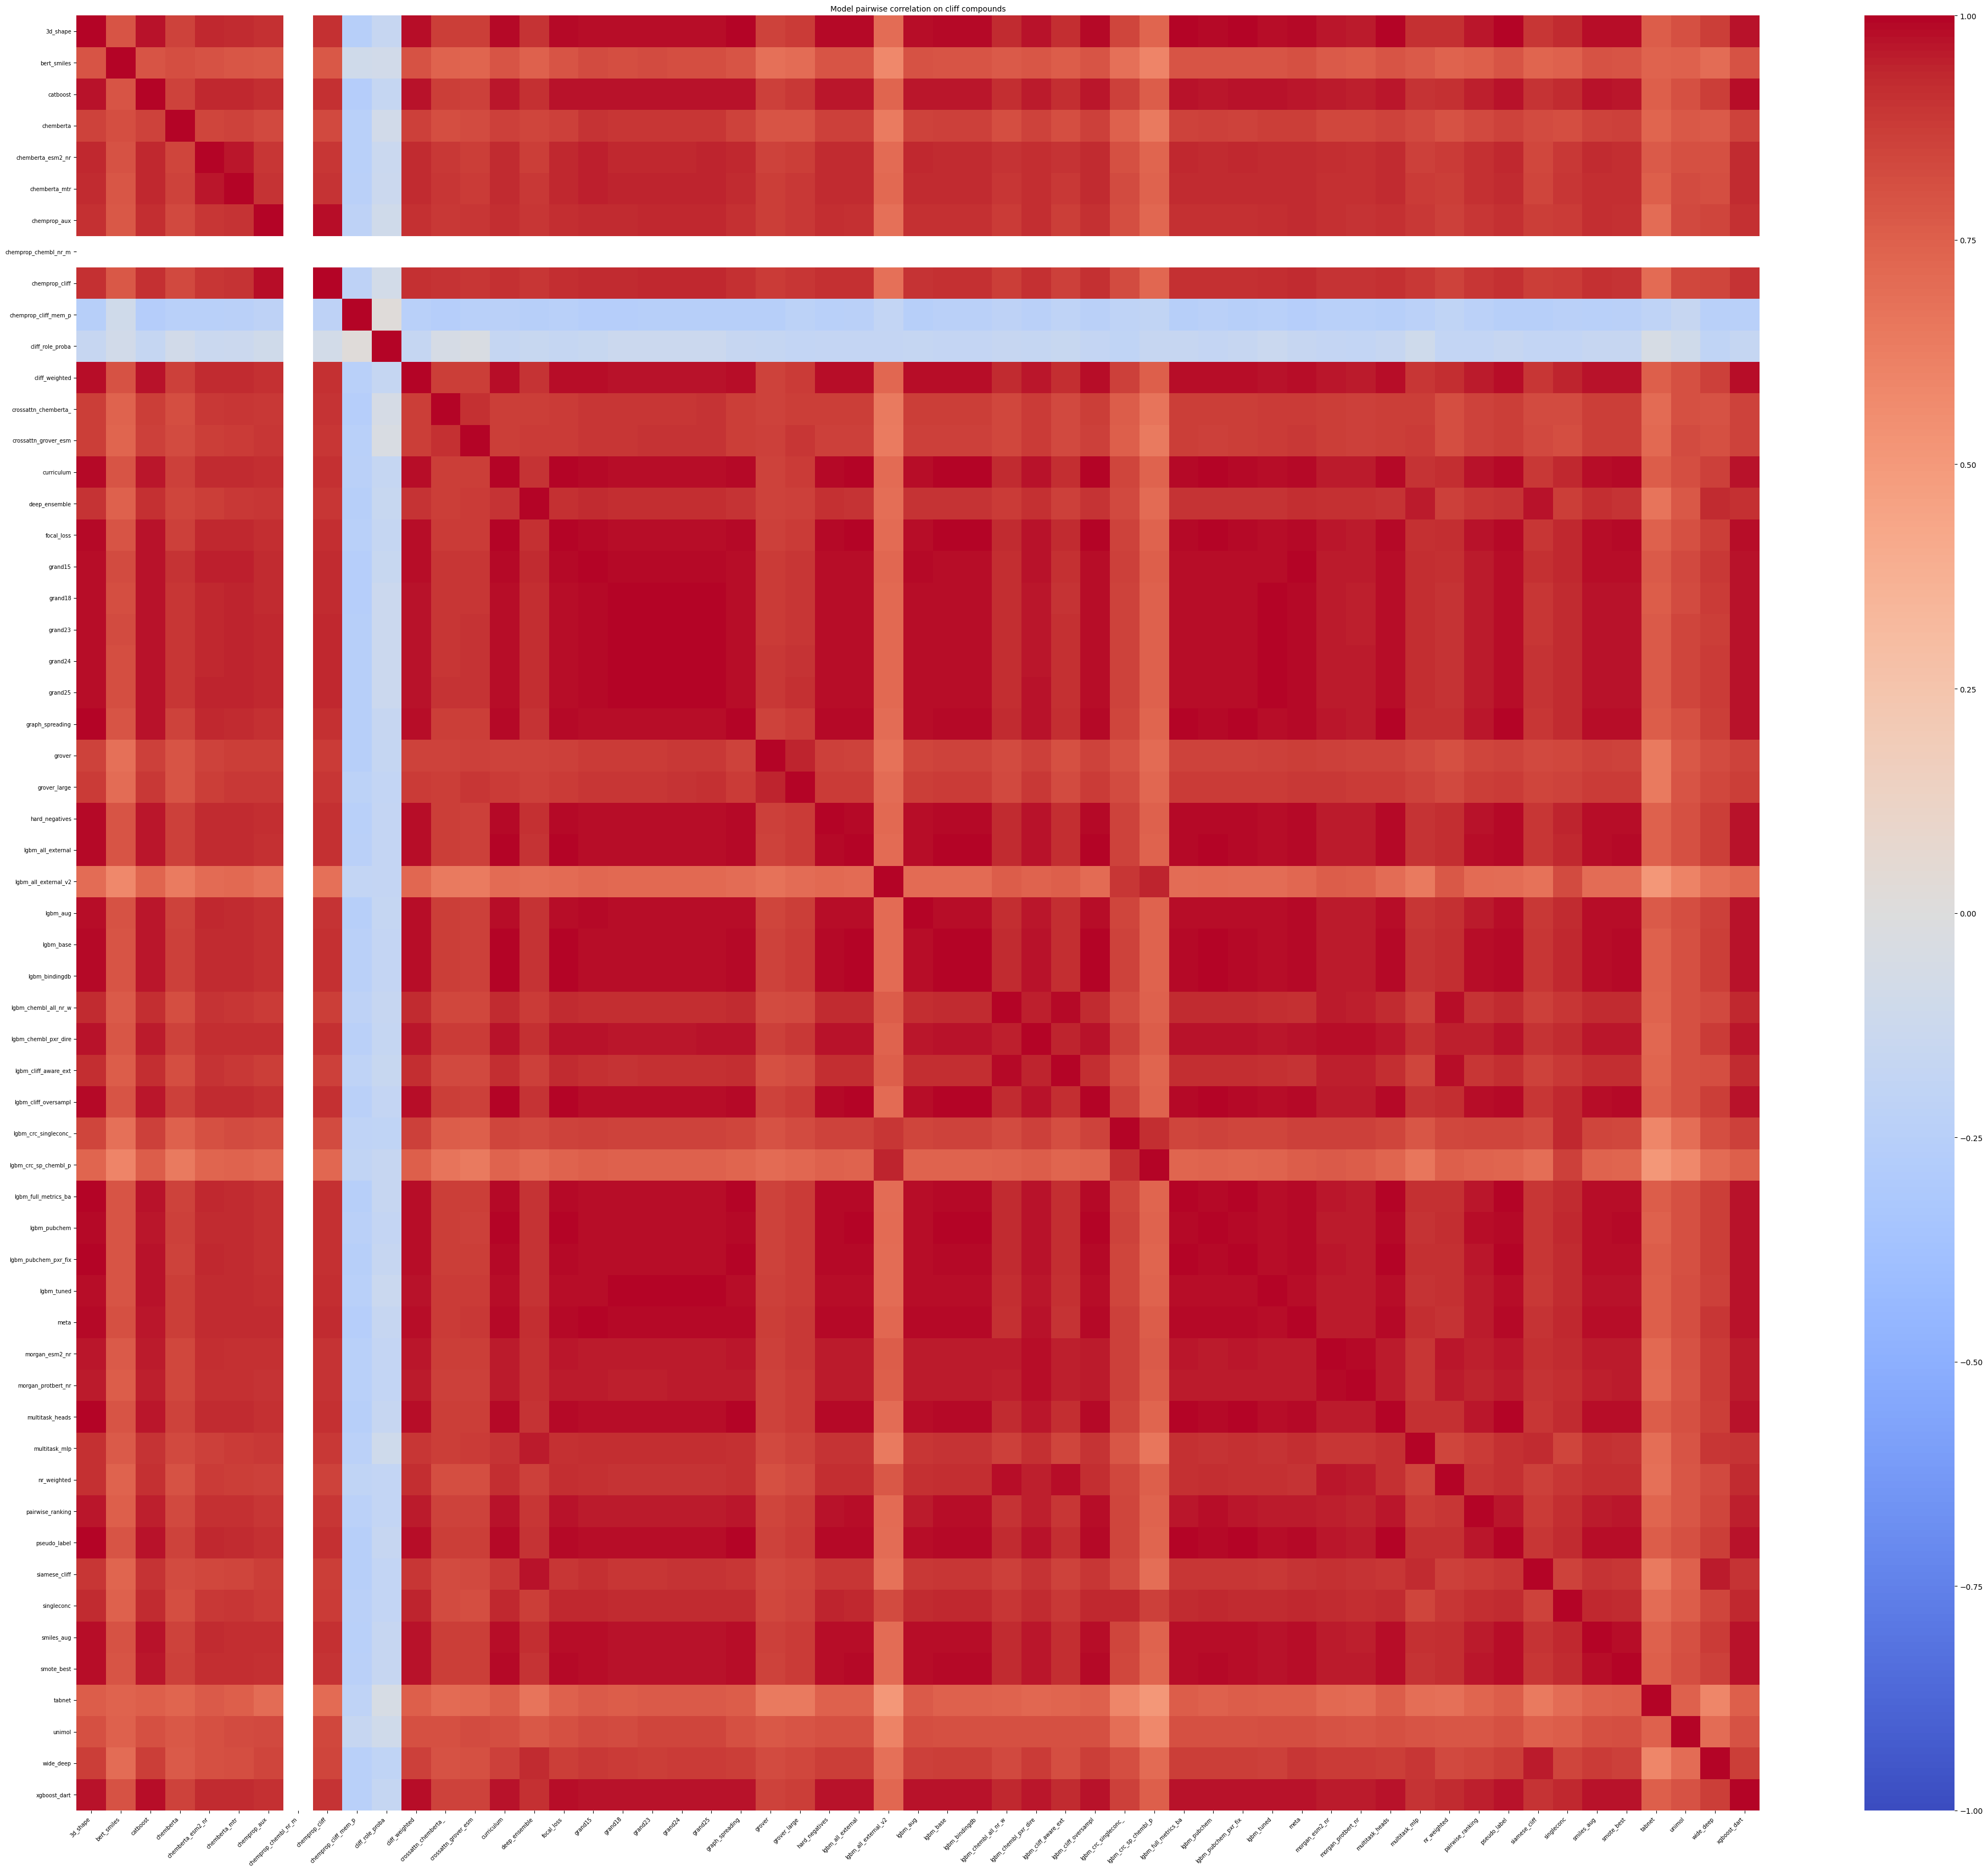

Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\data\processed\figures\cliff_model_diversity.png


In [5]:
if len(models) >= 2 and is_cliff_member.sum() > 5:
    # Pairwise Pearson correlation of OOF predictions on cliff compounds
    model_names = [m['name'] for m in models]
    oof_matrix_cliff = np.stack([m['oof'][is_cliff_member] for m in models], axis=0)  # (n_models, n_cliff)

    corr_matrix = np.corrcoef(oof_matrix_cliff)  # (n_models, n_models)

    # Find most uncorrelated pairs
    n_m = len(models)
    corr_rows = []
    for i in range(n_m):
        for j in range(i+1, n_m):
            corr_rows.append({'model_i': model_names[i], 'model_j': model_names[j],
                               'corr': float(corr_matrix[i, j])})

    corr_df = pd.DataFrame(corr_rows).sort_values('corr')

    print('=== Most diverse model pairs on cliff compounds (lowest correlation) ===')
    print(corr_df.head(15).to_string(index=False, float_format=lambda x: f'{x:.3f}'))

    # Mean correlation per model (lower = more diverse = more valuable for ensemble)
    mean_corr = []
    for i, name in enumerate(model_names):
        others = [corr_matrix[i, j] for j in range(n_m) if j != i]
        mean_corr.append({'model': name, 'mean_corr_with_others': float(np.mean(others))})
    mean_corr_df = pd.DataFrame(mean_corr).sort_values('mean_corr_with_others')
    print('\n=== Per-model mean correlation with others on cliff compounds ===')
    print('  (lower = more diverse = more valuable for ensemble diversity)')
    print(mean_corr_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

    # Heatmap
    try:
        import seaborn as sns
        fig, ax = plt.subplots(figsize=(max(6, n_m * 0.7), max(5, n_m * 0.6)))
        short_names = [n.replace('_lgbm', '').replace('_chemprop', '')[:20] for n in model_names]
        sns.heatmap(corr_matrix, xticklabels=short_names, yticklabels=short_names,
                    annot=(n_m <= 15), fmt='.2f', cmap='coolwarm', center=0,
                    vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7})
        ax.set_title('Model pairwise correlation on cliff compounds', fontsize=10)
        plt.xticks(fontsize=7, rotation=45, ha='right')
        plt.yticks(fontsize=7)
        plt.tight_layout()
        plt.savefig(FIGURES / 'cliff_model_diversity.png', dpi=120, bbox_inches='tight')
        plt.show()
        print(f'Saved: {FIGURES / "cliff_model_diversity.png"}')
    except ImportError:
        print('seaborn not available — skipping heatmap')
else:
    print('Need at least 2 models + cliff members for diversity analysis.')

## 5. Test set cliff proximity analysis

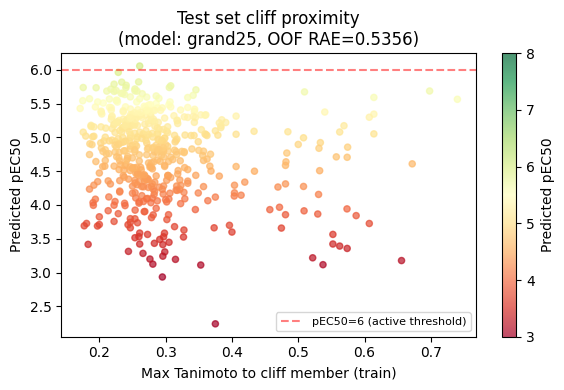

Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\data\processed\figures\test_cliff_proximity.png

Test-to-cliff Tanimoto statistics:
  Median: 0.274
  Mean:   0.296
  >0.5:   33 test compounds
  >0.7:   1 test compounds

Correlation (sim to cliff-active, predicted pEC50): -0.134
  Expected > 0: test compounds similar to cliff-actives should get higher predictions


In [6]:
if is_cliff_member.sum() > 0 and len(models) > 0:
    # Compute Tanimoto from each test compound to nearest cliff member in training
    fps_cliff_tr = morgan_fp_batch(
        tr.loc[is_cliff_member, 'smiles'].tolist()
    ).astype(np.float32)
    fps_te = morgan_fp_batch(te['smiles'].tolist()).astype(np.float32)

    dot = fps_te @ fps_cliff_tr.T
    rs_te = fps_te.sum(1, keepdims=True)
    rs_cl = fps_cliff_tr.sum(1)[None, :]
    union = rs_te + rs_cl - dot
    with np.errstate(divide='ignore', invalid='ignore'):
        tan_te_cliff = np.where(union > 0, dot / union, 0.0)

    max_sim_to_cliff = tan_te_cliff.max(axis=1)  # (n_test,)
    best_cliff_idx = tan_te_cliff.argmax(axis=1)  # which cliff member is closest

    # For each test compound: predicted pEC50 from best model
    if len(models) > 0:
        best_model_idx = np.argmin([m['oof_rae'] for m in models])
        best_model = models[best_model_idx]
        te_arr = best_model.get('te', None)
        if te_arr is not None and len(te_arr) == len(te):
            fig, ax = plt.subplots(figsize=(6, 4))
            sc = ax.scatter(max_sim_to_cliff, te_arr,
                             c=te_arr, cmap='RdYlGn',
                             vmin=3, vmax=8, s=20, alpha=0.7)
            plt.colorbar(sc, ax=ax, label='Predicted pEC50')
            ax.set_xlabel('Max Tanimoto to cliff member (train)')
            ax.set_ylabel('Predicted pEC50')
            ax.set_title(f'Test set cliff proximity\n(model: {best_model["name"]},'
                          f' OOF RAE={best_model["oof_rae"]:.4f})')
            ax.axhline(6.0, color='red', linestyle='--', alpha=0.5, label='pEC50=6 (active threshold)')
            ax.legend(fontsize=8)
            plt.tight_layout()
            plt.savefig(FIGURES / 'test_cliff_proximity.png', dpi=120, bbox_inches='tight')
            plt.show()
            print(f'Saved: {FIGURES / "test_cliff_proximity.png"}')

            print(f'\nTest-to-cliff Tanimoto statistics:')
            print(f'  Median: {np.median(max_sim_to_cliff):.3f}')
            print(f'  Mean:   {max_sim_to_cliff.mean():.3f}')
            print(f'  >0.5:   {(max_sim_to_cliff >= 0.5).sum():,} test compounds')
            print(f'  >0.7:   {(max_sim_to_cliff >= 0.7).sum():,} test compounds')

            # Correlation: higher sim to cliff-active → higher predicted pEC50?
            cliff_active_idx = np.where(is_cliff_active)[0]
            if len(cliff_active_idx) > 0:
                fps_cact = fps_cliff_tr[is_cliff_active[is_cliff_member]]  # cliff-active fps
                if len(fps_cact) > 0:
                    dot_cact = fps_te @ fps_cact.T
                    rs_cact = fps_cact.sum(1)[None, :]
                    union_cact = rs_te + rs_cact - dot_cact
                    with np.errstate(divide='ignore', invalid='ignore'):
                        tan_cact = np.where(union_cact > 0, dot_cact / union_cact, 0.0)
                    max_sim_to_cactive = tan_cact.max(axis=1)

                    corr = np.corrcoef(max_sim_to_cactive, te_arr)[0, 1]
                    print(f'\nCorrelation (sim to cliff-active, predicted pEC50): {corr:.3f}')
                    print('  Expected > 0: test compounds similar to cliff-actives should get higher predictions')
        else:
            print('Best model has no test predictions file')
else:
    print('No cliff members or no models — skipping test proximity analysis.')

## 6. Recommendations

In [7]:
print('=' * 75)
print('RECOMMENDATIONS FOR ENSEMBLE (ranked by cliff RAE)')
print('=' * 75)

if len(breakdown_df) > 0:
    # Merge with diversity info if available
    reco = breakdown_df.copy()

    if 'mean_corr_df' in dir():
        reco = reco.merge(mean_corr_df, on='model', how='left')

    # Cliff RAE < 0.6 means model is useful on cliff compounds
    good_cliff_models = reco[reco['cliff_rae'].notna() & (reco['cliff_rae'] < 0.6)]

    print(f'\nModels with cliff_member RAE < 0.6 (n={len(good_cliff_models)}):')
    if len(good_cliff_models) > 0:
        print(good_cliff_models[['model', 'overall_rae', 'cliff_rae']].to_string(
              index=False, float_format=lambda x: f'{x:.4f}'))
    else:
        print('  None found — all models struggle on cliffs.')

    print(f'\nTop 10 models overall (sorted by overall_rae):')
    top10 = reco.sort_values('overall_rae').head(10)
    print(top10[['model', 'overall_rae', 'cliff_rae', 'nocliff_rae']].to_string(
          index=False, float_format=lambda x: f'{x:.4f}'))

    print(f'\nKey insights:')
    if len(reco) > 0 and reco['cliff_rae'].notna().sum() > 0:
        best_cliff = reco.dropna(subset=['cliff_rae']).sort_values('cliff_rae').iloc[0]
        best_overall = reco.sort_values('overall_rae').iloc[0]
        print(f'  Best cliff model:   {best_cliff["model"]} (cliff RAE={best_cliff["cliff_rae"]:.4f})')
        print(f'  Best overall model: {best_overall["model"]} (overall RAE={best_overall["overall_rae"]:.4f})')
        if best_cliff['model'] != best_overall['model']:
            print('  Note: Different models win on cliffs vs overall — ensemble both!')

    # Save breakdown for nb62
    breakdown_df.to_parquet(DATA_PROCESSED / 'cliff_model_breakdown.parquet', index=False)
    print(f'\nSaved cliff_model_breakdown.parquet for use in nb62')
else:
    print('No models loaded — no recommendations available. Run notebooks 02–60 first.')

print('=' * 75)

RECOMMENDATIONS FOR ENSEMBLE (ranked by cliff RAE)

Models with cliff_member RAE < 0.6 (n=5):
     model  overall_rae  cliff_rae
lgbm_tuned       0.5394     0.5874
   grand18       0.5363     0.5927
   grand23       0.5360     0.5936
   grand24       0.5358     0.5936
   grand25       0.5356     0.5940

Top 10 models overall (sorted by overall_rae):
     model  overall_rae  cliff_rae  nocliff_rae
   grand25       0.5356     0.5940       0.5428
   grand24       0.5358     0.5936       0.5431
   grand23       0.5360     0.5936       0.5433
   grand18       0.5363     0.5927       0.5437
lgbm_tuned       0.5394     0.5874       0.5476
   grand15       0.5473     0.6088       0.5546
      meta       0.5517     0.6111       0.5592
focal_loss       0.5529     0.6113       0.5606
smote_best       0.5578     0.6154       0.5656
smiles_aug       0.5581     0.6095       0.5664

Key insights:
  Best cliff model:   lgbm_tuned (cliff RAE=0.5874)
  Best overall model: grand25 (overall RAE=0.5356)
  